In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../data/severity_dataset.csv")

In [8]:
df.head()

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan
0,1,74,Male,Fatigue,Sore throat,Fever,69,39.4,132/91,94,Flu,Moderate,Medication and rest
1,2,66,Female,Sore throat,Fatigue,Cough,95,39.0,174/98,98,Healthy,Mild,Rest and fluids
2,3,32,Male,Body ache,Sore throat,Fatigue,77,36.8,136/60,96,Healthy,Mild,Rest and fluids
3,4,21,Female,Shortness of breath,Headache,Cough,72,38.9,147/82,99,Healthy,Mild,Rest and fluids
4,5,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,109/106,92,Healthy,Mild,Rest and fluids


In [9]:
df.shape

(2000, 13)

In [10]:
# Display column names
print("Columns:")
print(df.columns.tolist())

Columns:
['Patient_ID', 'Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Blood_Pressure_mmHg', 'Oxygen_Saturation_%', 'Diagnosis', 'Severity', 'Treatment_Plan']


In [11]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.3+ KB


In [12]:
df.describe()

,Patient_ID,Age,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.285000,89.439000,37.741000,94.493500
std,577.494589,17.422616,17.139608,1.309835,2.861827
min,1.000000,18.000000,60.000000,35.500000,90.000000
25%,500.750000,33.000000,75.000000,36.600000,92.000000
50%,1000.500000,49.000000,89.000000,37.700000,95.000000
75%,1500.250000,63.000000,104.000000,38.900000,97.000000
max,2000.000000,79.000000,119.000000,40.000000,99.000000


In [13]:
df.describe(include="all")

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan
count,2000.000000,2000.000000,2000,2000,2000,2000,2000.000000,2000.000000,2000,2000.000000,2000,2000,2000
unique,NaN,NaN,2,8,8,8,NaN,NaN,1688,NaN,5,3,3
top,NaN,NaN,Male,Runny nose,Fatigue,Shortness of breath,NaN,NaN,93/90,NaN,Healthy,Mild,Rest and fluids
freq,NaN,NaN,1000,261,293,269,NaN,NaN,5,NaN,1167,1330,1330
mean,1000.500000,48.285000,NaN,NaN,NaN,NaN,89.439000,37.741000,NaN,94.493500,NaN,NaN,NaN
std,577.494589,17.422616,NaN,NaN,NaN,NaN,17.139608,1.309835,NaN,2.861827,NaN,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,NaN,60.000000,35.500000,NaN,90.000000,NaN,NaN,NaN
25%,500.750000,33.000000,NaN,NaN,NaN,NaN,75.000000,36.600000,NaN,92.000000,NaN,NaN,NaN
50%,1000.500000,49.000000,NaN,NaN,NaN,NaN,89.000000,37.700000,NaN,95.000000,NaN,NaN,NaN
75%,1500.250000,63.000000,NaN,NaN,NaN,NaN,104.000000,38.900000,NaN,97.000000,NaN,NaN,NaN


In [14]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Patient_ID             0
Age                    0
Gender                 0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Heart_Rate_bpm         0
Body_Temperature_C     0
Blood_Pressure_mmHg    0
Oxygen_Saturation_%    0
Diagnosis              0
Severity               0
Treatment_Plan         0
dtype: int64


In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
print("Severity Classes:")
print(df["Severity"].unique())

Severity Classes:
['Moderate' 'Mild' 'Severe']


In [17]:
print("Severity Distribution:")
print(df["Severity"].value_counts())

Severity Distribution:
Severity
Mild        1330
Severe       378
Moderate     292
Name: count, dtype: int64


In [18]:
categorical_columns = [
    "Gender",
    "Symptom_1",
    "Symptom_2",
    "Symptom_3",
    "Blood_Pressure_mmHg",
    "Severity"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      1000
Female    1000
Name: count, dtype: int64

--- Symptom_1 ---
Symptom_1
Runny nose             261
Shortness of breath    256
Body ache              255
Headache               252
Cough                  252
Fever                  250
Sore throat            238
Fatigue                236
Name: count, dtype: int64

--- Symptom_2 ---
Symptom_2
Fatigue                293
Cough                  288
Fever                  254
Body ache              244
Runny nose             240
Headache               237
Shortness of breath    231
Sore throat            213
Name: count, dtype: int64

--- Symptom_3 ---
Symptom_3
Shortness of breath    269
Fever                  267
Headache               264
Runny nose             255
Sore throat            246
Body ache              239
Cough                  233
Fatigue                227
Name: count, dtype: int64

--- Blood_Pressure_mmHg ---
Blood_Pressure_mmHg
93/90      5
99/115     4
167/106    4
144/76     4
100/77 

### EDA

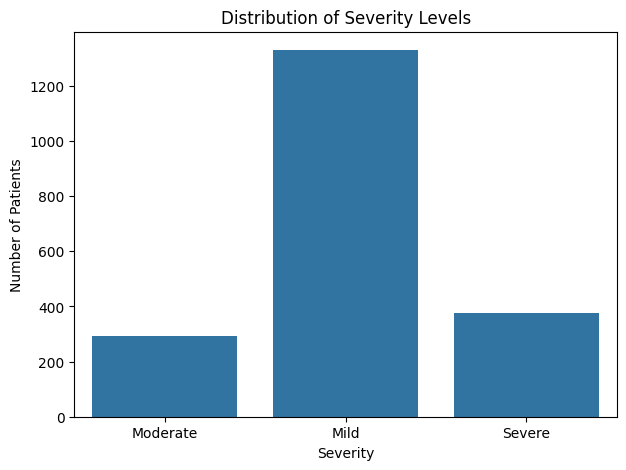

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Severity")

plt.title("Distribution of Severity Levels")
plt.xlabel("Severity")
plt.ylabel("Number of Patients")

plt.show()

In [20]:
df["Severity"].value_counts()

Severity
Mild        1330
Severe       378
Moderate     292
Name: count, dtype: int64

In [21]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['Patient_ID', 'Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']


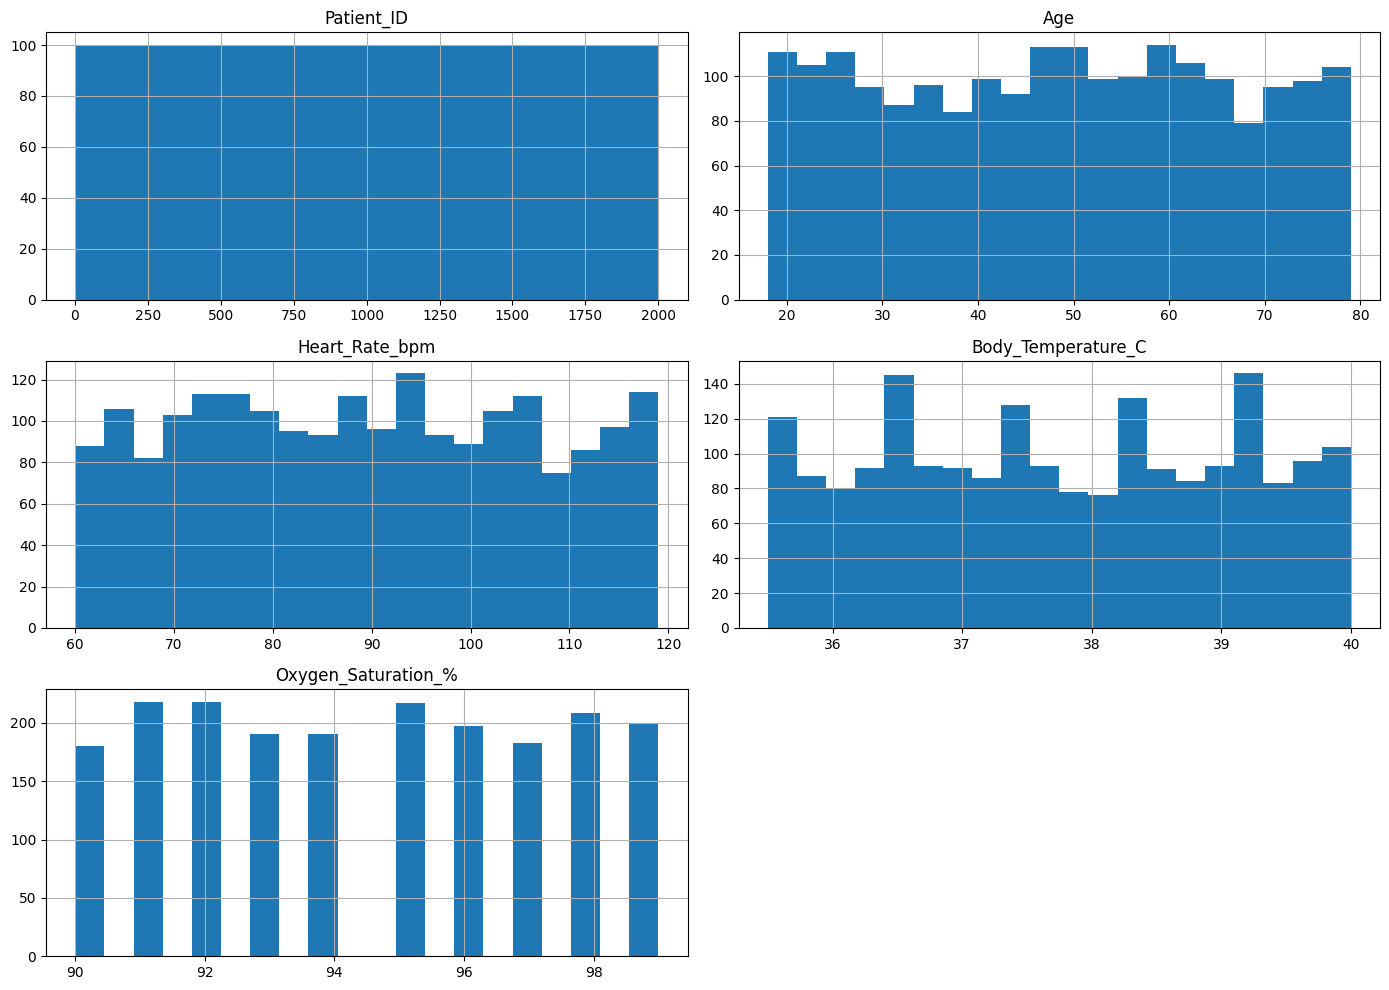

In [22]:
df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

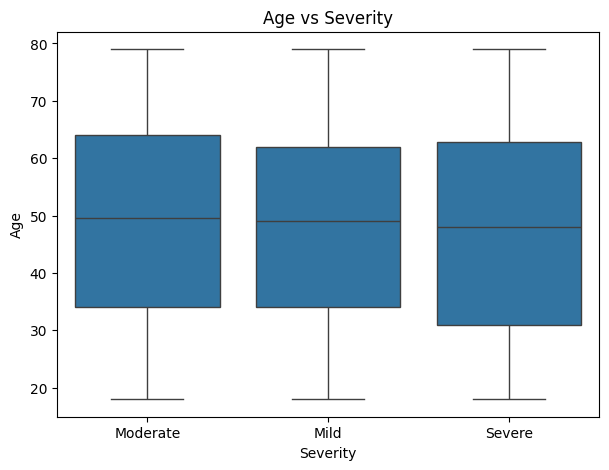

In [23]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Severity",
    y="Age"
)

plt.title("Age vs Severity")
plt.show()

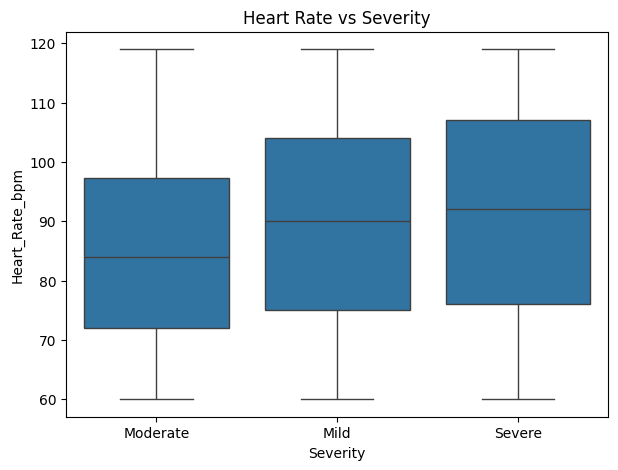

In [24]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Severity",
    y="Heart_Rate_bpm"
)

plt.title("Heart Rate vs Severity")
plt.show()

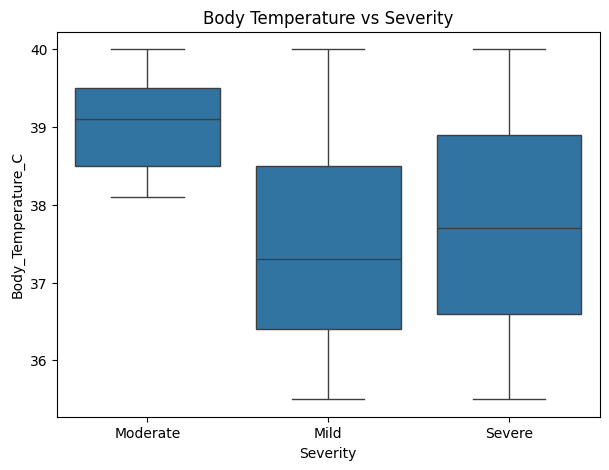

In [25]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Severity",
    y="Body_Temperature_C"
)

plt.title("Body Temperature vs Severity")
plt.show()

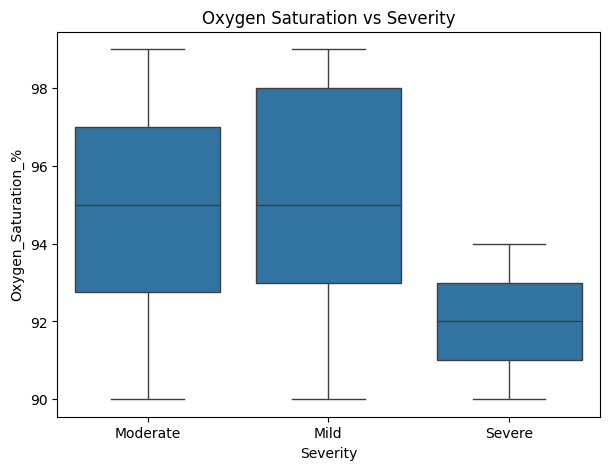

In [26]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Severity",
    y="Oxygen_Saturation_%"
)

plt.title("Oxygen Saturation vs Severity")
plt.show()

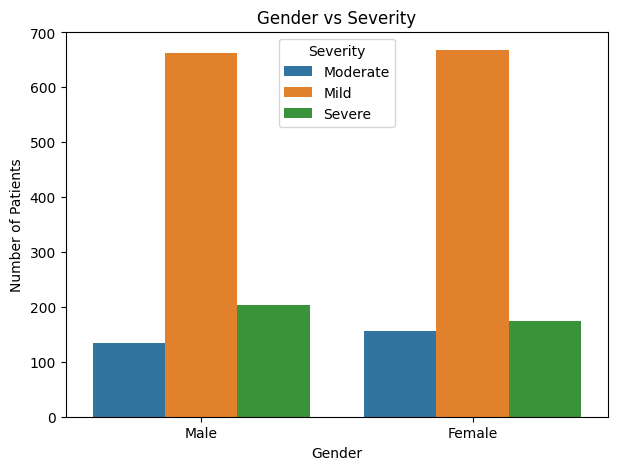

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Severity"
)

plt.title("Gender vs Severity")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

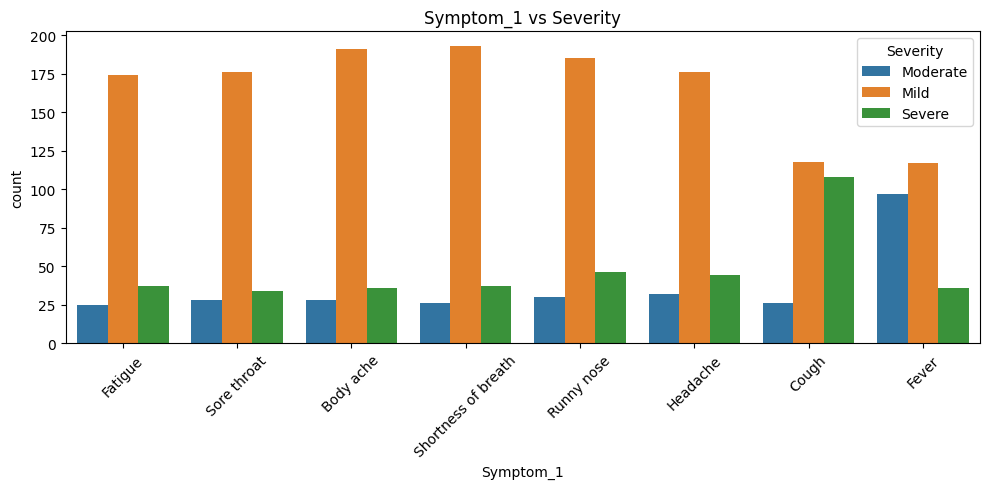

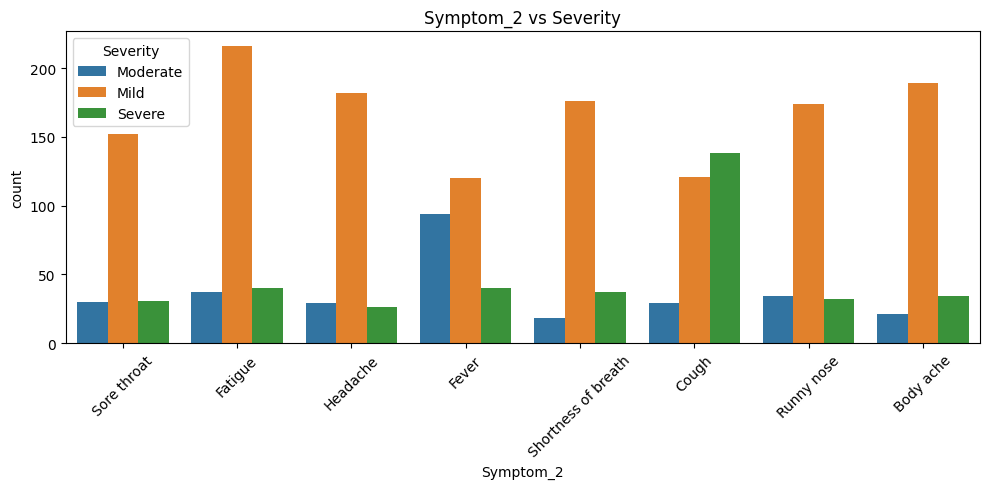

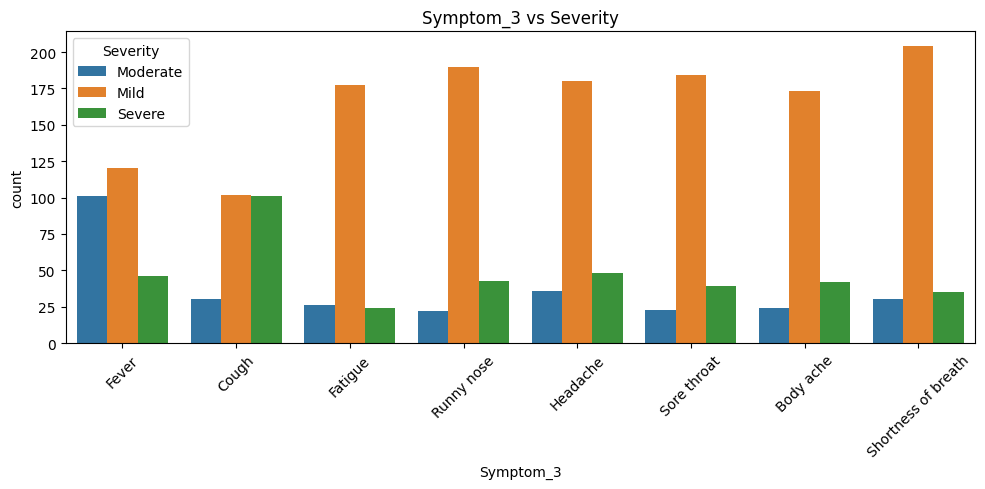

In [28]:
symptom_columns = [
    "Symptom_1",
    "Symptom_2",
    "Symptom_3"
]

for col in symptom_columns:
    
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=df,
        x=col,
        hue="Severity"
    )
    
    plt.title(f"{col} vs Severity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

In [29]:
print(df["Blood_Pressure_mmHg"].unique()[:20])

['132/91' '174/98' '136/60' '147/82' '109/106' '107/92' '126/82' '153/99'
 '152/71' '111/104' '152/62' '151/96' '149/113' '179/70' '125/98' '100/67'
 '131/67' '175/111' '169/93' '161/110']


In [30]:
print(df["Blood_Pressure_mmHg"].value_counts().head(20))

Blood_Pressure_mmHg
93/90      5
99/115     4
167/106    4
144/76     4
100/77     3
128/76     3
178/111    3
127/89     3
172/102    3
179/87     3
92/100     3
124/67     3
154/92     3
93/81      3
179/73     3
161/95     3
142/72     3
104/109    3
177/86     3
107/118    3
Name: count, dtype: int64


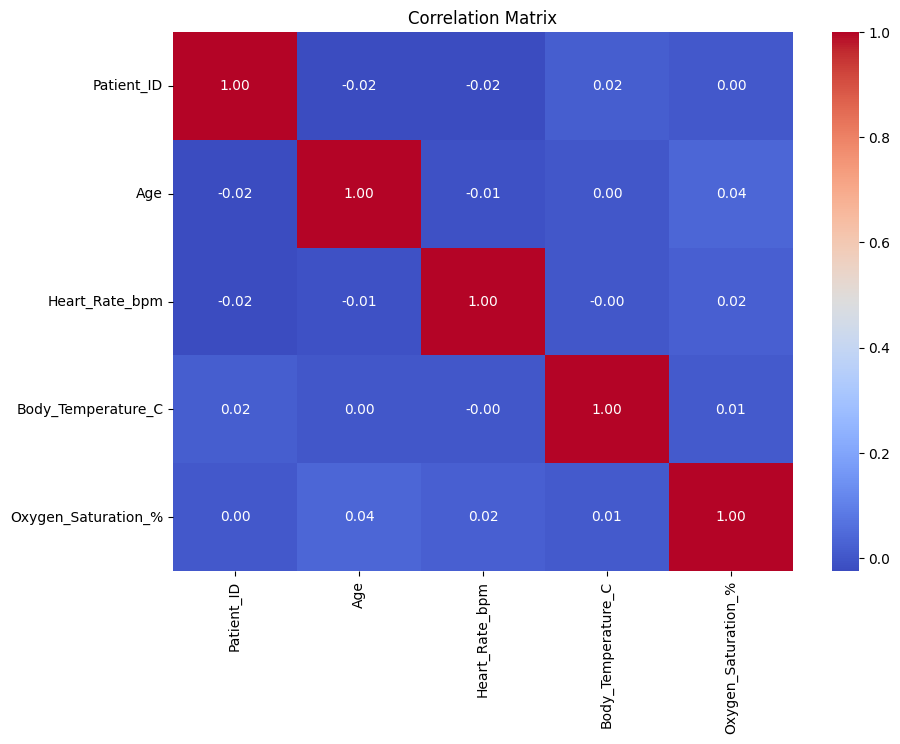

In [31]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [32]:
df_clean = df.copy()

In [33]:
columns_to_drop = [
    "Patient_ID",
    "Treatment_Plan",
    "Diagnosis"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Columns after dropping:")
print(df_clean.columns.tolist())

Columns after dropping:
['Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Blood_Pressure_mmHg', 'Oxygen_Saturation_%', 'Severity']


In [34]:
df_clean.isnull().sum()

Age                    0
Gender                 0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Heart_Rate_bpm         0
Body_Temperature_C     0
Blood_Pressure_mmHg    0
Oxygen_Saturation_%    0
Severity               0
dtype: int64

In [35]:
print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 0


In [36]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [37]:
df_clean[["Systolic_BP", "Diastolic_BP"]] = (
    df_clean["Blood_Pressure_mmHg"]
    .str.split("/", expand=True)
)

In [38]:
df_clean["Systolic_BP"] = pd.to_numeric(
    df_clean["Systolic_BP"],
    errors="coerce"
)

df_clean["Diastolic_BP"] = pd.to_numeric(
    df_clean["Diastolic_BP"],
    errors="coerce"
)

In [39]:
df_clean = df_clean.drop(
    columns=["Blood_Pressure_mmHg"]
)

In [40]:
df_clean.head()

,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Severity,Systolic_BP,Diastolic_BP
0,74,Male,Fatigue,Sore throat,Fever,69,39.4,94,Moderate,132,91
1,66,Female,Sore throat,Fatigue,Cough,95,39.0,98,Mild,174,98
2,32,Male,Body ache,Sore throat,Fatigue,77,36.8,96,Mild,136,60
3,21,Female,Shortness of breath,Headache,Cough,72,38.9,99,Mild,147,82
4,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,92,Mild,109,106


In [41]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2000 non-null   int64  
 1   Gender               2000 non-null   object 
 2   Symptom_1            2000 non-null   object 
 3   Symptom_2            2000 non-null   object 
 4   Symptom_3            2000 non-null   object 
 5   Heart_Rate_bpm       2000 non-null   int64  
 6   Body_Temperature_C   2000 non-null   float64
 7   Oxygen_Saturation_%  2000 non-null   int64  
 8   Severity             2000 non-null   object 
 9   Systolic_BP          2000 non-null   int64  
 10  Diastolic_BP         2000 non-null   int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 172.0+ KB


In [43]:
df_clean.isnull().sum()

Age                    0
Gender                 0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Heart_Rate_bpm         0
Body_Temperature_C     0
Oxygen_Saturation_%    0
Severity               0
Systolic_BP            0
Diastolic_BP           0
dtype: int64

In [44]:
df_clean.describe()

,Age,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Systolic_BP,Diastolic_BP
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,48.285000,89.439000,37.741000,94.493500,135.731500,89.338500
std,17.422616,17.139608,1.309835,2.861827,25.983879,17.295707
min,18.000000,60.000000,35.500000,90.000000,90.000000,60.000000
25%,33.000000,75.000000,36.600000,92.000000,114.000000,75.000000
50%,49.000000,89.000000,37.700000,95.000000,136.500000,90.000000
75%,63.000000,104.000000,38.900000,97.000000,159.000000,104.000000
max,79.000000,119.000000,40.000000,99.000000,179.000000,119.000000


In [45]:
print("Final Shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Final Shape: (2000, 11)

Columns:
['Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Severity', 'Systolic_BP', 'Diastolic_BP']

Missing Values:
Age                    0
Gender                 0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Heart_Rate_bpm         0
Body_Temperature_C     0
Oxygen_Saturation_%    0
Severity               0
Systolic_BP            0
Diastolic_BP           0
dtype: int64

Duplicate Rows:
0


In [46]:
X = df_clean.drop(columns=["Severity"])
y = df_clean["Severity"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 10)
Target shape: (2000,)


In [48]:
print("Numerical Features:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Features:")
print(X.select_dtypes(include="object").columns.tolist())

Numerical Features:
['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']

Categorical Features:
['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3']


In [49]:
print(y.unique())

['Moderate' 'Mild' 'Severe']


In [50]:
print(y.value_counts())

Severity
Mild        1330
Severe       378
Moderate     292
Name: count, dtype: int64


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1600, 10)
Testing set : (400, 10)


In [53]:
print("\nTraining Severity Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Severity Distribution:")
print(y_test.value_counts(normalize=True) * 100)


Training Severity Distribution:
Severity
Mild        66.500
Severe      18.875
Moderate    14.625
Name: proportion, dtype: float64

Testing Severity Distribution:
Severity
Mild        66.5
Severe      19.0
Moderate    14.5
Name: proportion, dtype: float64


In [54]:
numerical_features = [
    "Age",
    "Heart_Rate_bpm",
    "Body_Temperature_C",
    "Oxygen_Saturation_%",
    "Systolic_BP",
    "Diastolic_BP"
]

categorical_features = [
    "Gender",
    "Symptom_1",
    "Symptom_2",
    "Symptom_3"
]

In [55]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [57]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

In [58]:
print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_transformed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Transformed testing shape:", X_test_transformed.shape)

Original training shape: (1600, 10)
Transformed training shape: (1600, 32)

Original testing shape: (400, 10)
Transformed testing shape: (400, 32)


In [59]:
X_train

,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Systolic_BP,Diastolic_BP
224,59,Male,Body ache,Runny nose,Fatigue,70,36.9,99,169,110
570,33,Male,Fatigue,Fever,Sore throat,64,39.0,99,109,96
1919,52,Male,Sore throat,Headache,Shortness of breath,110,38.1,97,155,92
1575,35,Female,Fatigue,Runny nose,Fever,90,35.7,91,133,105
1756,58,Male,Body ache,Fatigue,Runny nose,102,35.9,92,127,63
...,...,...,...,...,...,...,...,...,...,...
6,21,Male,Sore throat,Fatigue,Cough,71,37.5,93,126,82
1412,51,Male,Fever,Headache,Runny nose,101,38.5,91,172,60
1159,18,Male,Runny nose,Fatigue,Shortness of breath,86,36.5,91,138,110
100,54,Male,Fever,Runny nose,Headache,80,37.9,90,171,76


In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [62]:
logistic_model.fit(
    X_train_transformed,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [63]:
y_pred = logistic_model.predict(X_test_transformed)

print("Predictions:")
print(y_pred[:20])

Predictions:
['Mild' 'Moderate' 'Mild' 'Mild' 'Moderate' 'Mild' 'Mild' 'Severe' 'Mild'
 'Mild' 'Mild' 'Mild' 'Mild' 'Mild' 'Moderate' 'Moderate' 'Mild' 'Mild'
 'Mild' 'Mild']


In [64]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,Mild,Mild
1,Moderate,Moderate
2,Mild,Mild
3,Mild,Mild
4,Moderate,Moderate
5,Mild,Mild
6,Mild,Mild
7,Severe,Severe
8,Mild,Mild
9,Mild,Mild


In [65]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.94


In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [67]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.94
Precision: 0.9392592592592592
Recall   : 0.94
F1 Score : 0.9394349680170576


In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Mild       0.96      0.98      0.97       266
    Moderate       0.89      0.83      0.86        58
      Severe       0.89      0.89      0.89        76

    accuracy                           0.94       400
   macro avg       0.92      0.90      0.91       400
weighted avg       0.94      0.94      0.94       400



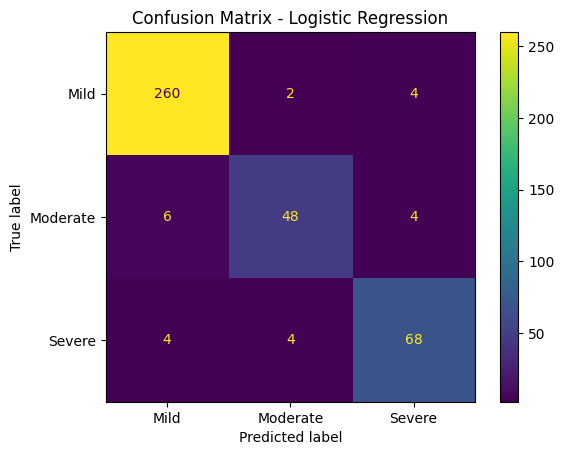

In [69]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Mild", "Moderate", "Severe"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Mild", "Moderate", "Severe"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [70]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,Mild,Mild
1,Moderate,Moderate
2,Mild,Mild
3,Mild,Mild
4,Moderate,Moderate
5,Mild,Mild
6,Mild,Mild
7,Severe,Severe
8,Mild,Mild
9,Mild,Mild


In [71]:
incorrect = comparison[
    comparison["Actual"] != comparison["Predicted"]
]

print("Incorrect predictions:", len(incorrect))

incorrect.head(20)

Incorrect predictions: 24


,Actual,Predicted
12,Moderate,Mild
38,Moderate,Mild
39,Moderate,Mild
76,Severe,Mild
78,Severe,Moderate
82,Moderate,Severe
100,Moderate,Mild
106,Mild,Severe
109,Moderate,Severe
110,Severe,Moderate


In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [74]:
random_forest.fit(
    X_train_transformed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
rf_pred = random_forest.predict(
    X_test_transformed
)

In [76]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("Random Forest")
print("----------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
----------------
Accuracy : 0.9875
Precision: 0.9875604519774012
Recall   : 0.9875
F1 Score : 0.9875120280749421


In [77]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       266
    Moderate       0.95      0.97      0.96        58
      Severe       0.97      0.96      0.97        76

    accuracy                           0.99       400
   macro avg       0.97      0.98      0.97       400
weighted avg       0.99      0.99      0.99       400



In [78]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9400,0.939259,0.9400,0.939435
1,Random Forest,0.9875,0.987560,0.9875,0.987512


In [79]:
from sklearn.ensemble import GradientBoostingClassifier

In [80]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [81]:
gradient_boosting.fit(
    X_train_transformed,
    y_train
)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [82]:
gb_pred = gradient_boosting.predict(
    X_test_transformed
)

In [83]:
gb_accuracy = accuracy_score(y_test, gb_pred)

gb_precision = precision_score(
    y_test,
    gb_pred,
    average="weighted"
)

gb_recall = recall_score(
    y_test,
    gb_pred,
    average="weighted"
)

gb_f1 = f1_score(
    y_test,
    gb_pred,
    average="weighted"
)

print("Gradient Boosting")
print("------------------")
print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)

Gradient Boosting
------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [84]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       266
    Moderate       1.00      1.00      1.00        58
      Severe       1.00      1.00      1.00        76

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [85]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        gb_f1
    ]
})

model_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Gradient Boosting,1.0000,1.000000,1.0000,1.000000
1,Random Forest,0.9875,0.987560,0.9875,0.987512
0,Logistic Regression,0.9400,0.939259,0.9400,0.939435


In [86]:
from sklearn.metrics import precision_recall_fscore_support

models_predictions = {
    "Logistic Regression": y_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

results = []

for model_name, predictions in models_predictions.items():

    precision_values, recall_values, f1_values, support_values = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            labels=["Mild", "Moderate", "Severe"]
        )
    )

    severe_index = 2

    results.append({
        "Model": model_name,
        "Severe Precision": precision_values[severe_index],
        "Severe Recall": recall_values[severe_index],
        "Severe F1": f1_values[severe_index]
    })

severe_comparison = pd.DataFrame(results)

severe_comparison.sort_values(
    by="Severe F1",
    ascending=False
)

,Model,Severe Precision,Severe Recall,Severe F1
2,Gradient Boosting,1.000000,1.000000,1.000000
1,Random Forest,0.973333,0.960526,0.966887
0,Logistic Regression,0.894737,0.894737,0.894737


In [87]:
from sklearn.model_selection import GridSearchCV

In [88]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [89]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [90]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

In [91]:
grid_search.fit(
    X_train_transformed,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [92]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [93]:
print("Best Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Cross-Validation F1 Score:
0.9830935902379172


In [94]:
best_rf = grid_search.best_estimator_

In [95]:
tuned_rf_pred = best_rf.predict(
    X_test_transformed
)

In [96]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_rf_pred,
    average="weighted"
)

tuned_recall = recall_score(
    y_test,
    tuned_rf_pred,
    average="weighted"
)

tuned_f1 = f1_score(
    y_test,
    tuned_rf_pred,
    average="weighted"
)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned Random Forest
-------------------
Accuracy : 0.99
Precision: 0.99
Recall   : 0.99
F1 Score : 0.99


In [97]:
print(
    classification_report(
        y_test,
        tuned_rf_pred
    )
)

              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       266
    Moderate       0.97      0.97      0.97        58
      Severe       0.97      0.97      0.97        76

    accuracy                           0.99       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.99      0.99      0.99       400



In [98]:
comparison_tuning = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        rf_recall,
        tuned_recall
    ],
    "F1 Score": [
        rf_f1,
        tuned_f1
    ]
})

comparison_tuning

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9875,0.98756,0.9875,0.987512
1,Tuned Random Forest,0.9900,0.99000,0.9900,0.990000


In [99]:
print(
    classification_report(
        y_test,
        tuned_rf_pred,
        labels=["Mild", "Moderate", "Severe"]
    )
)

              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       266
    Moderate       0.97      0.97      0.97        58
      Severe       0.97      0.97      0.97        76

    accuracy                           0.99       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.99      0.99      0.99       400



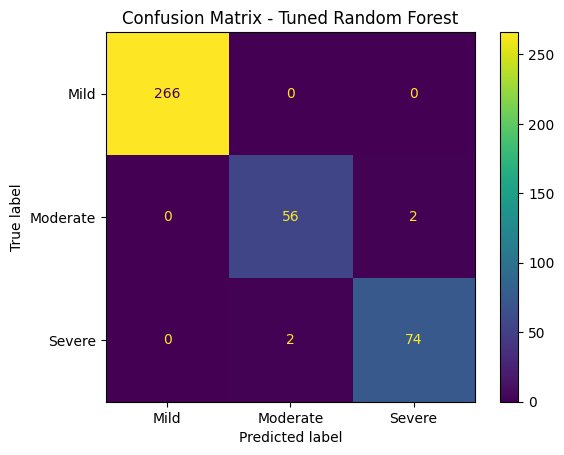

In [100]:
cm = confusion_matrix(
    y_test,
    tuned_rf_pred,
    labels=["Mild", "Moderate", "Severe"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Mild", "Moderate", "Severe"]
)

disp.plot()

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [101]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        gb_precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        gb_recall,
        tuned_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        gb_f1,
        tuned_f1
    ]
})

final_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Gradient Boosting,1.0000,1.000000,1.0000,1.000000
3,Tuned Random Forest,0.9900,0.990000,0.9900,0.990000
1,Random Forest,0.9875,0.987560,0.9875,0.987512
0,Logistic Regression,0.9400,0.939259,0.9400,0.939435


In [102]:
final_classifier = best_rf

In [103]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", final_classifier)
])

In [104]:
final_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [105]:
final_predictions = final_pipeline.predict(
    X_test
)

In [106]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted"
)

final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted"
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted"
)

print("Final Model Performance")
print("------------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

Final Model Performance
------------------------
Accuracy : 0.99
Precision: 0.99
Recall   : 0.99
F1 Score : 0.99


In [107]:
print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       266
    Moderate       0.97      0.97      0.97        58
      Severe       0.97      0.97      0.97        76

    accuracy                           0.99       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.99      0.99      0.99       400



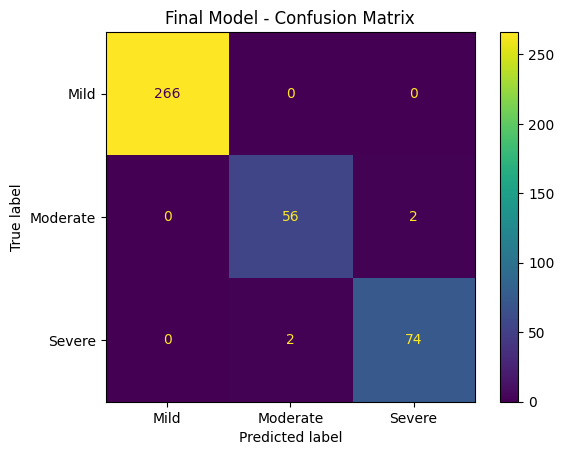

In [108]:
cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=["Mild", "Moderate", "Severe"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Mild", "Moderate", "Severe"]
)

disp.plot()

plt.title("Final Model - Confusion Matrix")
plt.show()

In [109]:
probabilities = final_pipeline.predict_proba(X_test)

print(probabilities[:5])

[[0.93 0.02 0.05]
 [0.14 0.84 0.02]
 [0.81 0.06 0.13]
 [0.94 0.   0.06]
 [0.23 0.75 0.02]]


In [110]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_pipeline,
    "../models/severity_pipeline.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [111]:
# Test the saved model

loaded_pipeline = joblib.load(
    "../models/severity_pipeline.pkl"
)

test_predictions = loaded_pipeline.predict(
    X_test
)

print(test_predictions[:10])

['Mild' 'Moderate' 'Mild' 'Mild' 'Moderate' 'Mild' 'Mild' 'Severe' 'Mild'
 'Mild']


In [112]:
print(
    "Loaded model accuracy:",
    accuracy_score(y_test, test_predictions)
)

Loaded model accuracy: 0.99
